In [1]:
!pip install netCDF4 xarray numpy pandas matplotlib torch xgboostlss scipy optuna optuna-integration statsmodels tqdm shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 22.5 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nvshmem-cu12
    

In [3]:
"""
IISE ESD Data Competition 2026 — Final Submission Code (v5)

XGBoostLSS with ZINB distribution + SARIMAX Ensemble.

This is the production version incorporating all lessons from v1–v4:
  - ZINB distribution (confirmed best via comparison)
  - Direct multi-horizon training (train matches test conditions)
  - Distribution MEAN for point prediction (not median)
  - ALL origins with denser subsampled horizons
  - Optimally weighted SARIMAX + XGBoostLSS ensemble
  - SHAP feature importance analysis for written report
  - Proper submission format matching template

Produces TWO submission files:
  1. xgboostlss_pred_48h.csv  — standalone (best s4 Winkler)
  2. ensemble_pred_48h.csv    — blended (best s1, s2, s3)

Built upon demo.ipynb structure.
"""

'\nIISE ESD Data Competition 2026 — Final Submission Code (v5)\n\nXGBoostLSS with ZINB distribution + SARIMAX Ensemble.\n\nThis is the production version incorporating all lessons from v1–v4:\n  - ZINB distribution (confirmed best via comparison)\n  - Direct multi-horizon training (train matches test conditions)\n  - Distribution MEAN for point prediction (not median)\n  - ALL origins with denser subsampled horizons\n  - Optimally weighted SARIMAX + XGBoostLSS ensemble\n  - SHAP feature importance analysis for written report\n  - Proper submission format matching template\n\nProduces TWO submission files:\n  1. xgboostlss_pred_48h.csv  — standalone (best s4 Winkler)\n  2. ensemble_pred_48h.csv    — blended (best s1, s2, s3)\n\nBuilt upon demo.ipynb structure.\n'

In [4]:
# ============================================================================
# 1. PREREQUISITES
# ============================================================================


import sys
for pkg, imp in {'numpy':'numpy','pandas':'pandas','xarray':'xarray',
                 'netCDF4':'netCDF4','matplotlib':'matplotlib','torch':'torch',
                 'statsmodels':'statsmodels','tqdm':'tqdm',
                 'xgboost':'xgboost','xgboostlss':'xgboostlss'}.items():
    try: __import__(imp); print(f"  [OK] {pkg}")
    except ImportError: print(f"  [MISSING] {pkg}")

  [OK] numpy
  [OK] pandas
  [OK] xarray
  [OK] netCDF4
  [OK] matplotlib
  [OK] torch
  [OK] statsmodels
  [OK] tqdm
  [OK] xgboost
  [OK] xgboostlss


In [5]:
# ============================================================================
# 2. CONFIGURATION & SETUP
# ============================================================================
import os, gc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
import torch, multiprocessing
import xgboost as xgb

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---- PATHS: ADJUST THESE ----
# Data paths - adjust these to your data directory
DATA_DIR = "/content/drive/MyDrive/iise/dataset/data"
RESULTS_DIR = "/content/drive/MyDrive/iise/dataset/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")
if not os.path.exists(TRAIN_PATH):
    TRAIN_PATH = os.path.join(DATA_DIR, "train_small.nc")
    print("WARNING: Using train_small.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Demo baseline
VALIDATION_SPLIT = 0.2
SARIMAX_ORDER = (1, 0, 1)

# XGBoostLSS — production settings (higher budget than v4)
XGBLSS_N_ITERATIONS = 500
XGBLSS_EARLY_STOP = 30
XGBLSS_OPTUNA_TRIALS = 30

# Feature engineering
MAX_HORIZON = 48
TRAIN_HORIZONS = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 42, 48]
LOOKBACK_LAGS = [1, 2, 3, 6, 12, 24]
ROLLING_WINDOWS = [3, 6, 12, 24]
KEY_WEATHER_FEATURES = [
    'gust','cape','cape_1','max_10si','mslma','fricv','cnwat','tcc_1',
    'v10','sp','mstav','prate','vis','lcc','hail','ltng','refc','cin',
    'lftx','sh2','d2m','t2m','r2','blh','u10','v','u','tp','sdswrf','pwat',
]

PI_LOWER, PI_UPPER = 0.025, 0.975
N_CPU = multiprocessing.cpu_count()

print(f"\n{'='*70}")
print(f"IISE ESD 2026 — XGBoostLSS + Ensemble (v5 Production)")
print(f"{'='*70}")
print(f"Seed: {RANDOM_SEED}, CPUs: {N_CPU}")
print(f"Horizons ({len(TRAIN_HORIZONS)}): {TRAIN_HORIZONS}")
print(f"Optuna: {XGBLSS_OPTUNA_TRIALS} trials, {XGBLSS_N_ITERATIONS} max rounds")


IISE ESD 2026 — XGBoostLSS + Ensemble (v5 Production)
Seed: 42, CPUs: 48
Horizons (16): [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 42, 48]
Optuna: 30 trials, 500 max rounds


In [6]:
# ============================================================================
# 3. DATA LOADING
# ============================================================================
print(f"\n{'='*70}\n3. DATA LOADING\n{'='*70}")

ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"  {len(train_timestamps)} timestamps, {len(locations)} counties, {len(weather_features)} weather features")
outage_data = ds_train.out.transpose("timestamp","location").values.astype(float)
print(f"  Outage: mean={np.nanmean(outage_data):.2f}, zero%={100*(outage_data==0).mean():.1f}%, max={np.nanmax(outage_data):.0f}")

test_48h_timestamps = pd.to_datetime(ds_test_48h.timestamp.values)
print(f"Test: {test_48h_timestamps.min()} to {test_48h_timestamps.max()} ({len(test_48h_timestamps)}h)")


3. DATA LOADING
Training: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
  2161 timestamps, 83 counties, 109 weather features
  Outage: mean=45.25, zero%=70.5%, max=23346
Test: 2023-06-30 01:00:00 to 2023-07-02 00:00:00 (48h)


In [7]:
# ============================================================================
# 4. EDA
# ============================================================================
print(f"\n{'='*70}\n4. EDA\n{'='*70}")
pop_by_loc = ds_train.tracked.mean(dim="timestamp")
top5_locs = pop_by_loc.sortby(pop_by_loc, ascending=False).isel(location=slice(0,5)).location.values
print("Top 5 counties:", [str(x) for x in top5_locs])



4. EDA
Top 5 counties: ['26163', '26125', '26099', '26081', '26049']


In [8]:
# ============================================================================
# 5. DATA PREPARATION
# ============================================================================
print(f"\n{'='*70}\n5. DATA PREPARATION\n{'='*70}")

split_idx = int(len(train_timestamps) * (1 - VALIDATION_SPLIT))
ds_train_sub = ds_train.isel(timestamp=slice(0, split_idx))
ds_val = ds_train.isel(timestamp=slice(split_idx, None))
train_sub_ts = pd.to_datetime(ds_train_sub.timestamp.values)
val_ts = pd.to_datetime(ds_val.timestamp.values)

print(f"Train: {len(train_sub_ts)} ts ({train_sub_ts.min()} -> {train_sub_ts.max()})")
print(f"Val:   {len(val_ts)} ts ({val_ts.min()} -> {val_ts.max()})")

val_truth = ds_val.out.transpose("timestamp","location").isel(timestamp=slice(0,48)).values.astype(float)
test_truth = ds_test_48h.out.transpose("timestamp","location").values.astype(float)
print(f"Val truth: {val_truth.shape}, Test truth: {test_truth.shape}")


5. DATA PREPARATION
Train: 1728 ts (2023-04-01 00:00:00 -> 2023-06-11 23:00:00)
Val:   433 ts (2023-06-12 00:00:00 -> 2023-06-30 00:00:00)
Val truth: (48, 83), Test truth: (48, 83)


In [23]:

# ============================================================================
# 6. MODEL FUNCTIONS
# ============================================================================
print(f"\n{'='*70}\n6. MODEL FUNCTIONS\n{'='*70}")

# ---- 6.1 SARIMAX (from demo.ipynb) ----
from statsmodels.tsa.statespace.sarimax import SARIMAX

def safe_fit_sarimax(y, order=(1,0,1)):
    y = np.asarray(y,dtype=float).flatten()
    if len(y)<8 or np.allclose(y,y[0]): return None
    try:
        return SARIMAX(y,order=order,enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
    except: return None

def generate_sarimax_predictions(models, locations, timestamps):
    rows = []
    n = len(timestamps)
    for loc in locations:
        ls = str(loc)
        if ls in models and models[ls] is not None:
            try: pred = np.clip(np.asarray(models[ls].forecast(steps=n),float),0,None)
            except: pred = np.zeros(n)
        else: pred = np.zeros(n)
        rows.append(pd.DataFrame({"timestamp":timestamps,"location":ls,"pred":pred}))
    return pd.concat(rows, ignore_index=True)

# ---- 6.2 Feature Engineering ----
from xgboostlss.model import XGBoostLSS
from xgboostlss.distributions.ZINB import ZINB

def identify_weather(wf, kf):
    return [f for f in kf if f in wf]

def _feat_names(aw):
    c = ['hour_sin','hour_cos','dow_sin','dow_cos','is_weekend','hour_raw',
         'forecast_horizon','tracked_log','county_id','out_current']
    for l in LOOKBACK_LAGS: c.append(f'out_lag{l}')
    for w in ROLLING_WINDOWS: c.extend([f'out_rmean{w}',f'out_rmax{w}',f'out_rstd{w}'])
    for f in aw: c.append(f'wx_{f}')
    for f in aw:
        for w in [6,24]: c.extend([f'wx_{f}_rmean{w}',f'wx_{f}_rmax{w}'])
    for f in aw[:10]: c.append(f'wx_{f}_trend3')
    return c

def _origin_feats(out,trk,wth,ai,aw,t,L):
    o = {}
    o['out_current']=out[t,:]; o['tracked_log']=np.log1p(trk[t,:])
    for l in LOOKBACK_LAGS:
        tl=t-l; o[f'out_lag{l}']=out[tl,:] if tl>=0 else np.zeros(L)
    for w in ROLLING_WINDOWS:
        s=max(0,t-w+1); d=out[s:t+1,:]
        o[f'out_rmean{w}']=d.mean(0); o[f'out_rmax{w}']=d.max(0); o[f'out_rstd{w}']=d.std(0)
    for fi,fn in zip(ai,aw): o[f'wx_{fn}']=wth[t,:,fi]
    for fi,fn in zip(ai,aw):
        for w in [6,24]:
            s=max(0,t-w+1); d=wth[s:t+1,:,fi]
            o[f'wx_{fn}_rmean{w}']=d.mean(0); o[f'wx_{fn}_rmax{w}']=d.max(0)
    for fi,fn in zip(ai[:10],aw[:10]):
        o[f'wx_{fn}_trend3']=(wth[t,:,fi]-wth[t-3,:,fi]) if t>=3 else np.zeros(L)
    return o

def _fill(X,i,o,tmp,li,aw):
    X[i,:7]=tmp; X[i,7]=o['tracked_log'][li]; X[i,8]=float(li); X[i,9]=o['out_current'][li]
    c=10
    for l in LOOKBACK_LAGS: X[i,c]=o[f'out_lag{l}'][li]; c+=1
    for w in ROLLING_WINDOWS:
        X[i,c]=o[f'out_rmean{w}'][li]; c+=1
        X[i,c]=o[f'out_rmax{w}'][li]; c+=1
        X[i,c]=o[f'out_rstd{w}'][li]; c+=1
    for fn in aw: X[i,c]=o[f'wx_{fn}'][li]; c+=1
    for fn in aw:
        for w in [6,24]: X[i,c]=o[f'wx_{fn}_rmean{w}'][li]; c+=1; X[i,c]=o[f'wx_{fn}_rmax{w}'][li]; c+=1
    for fn in aw[:10]: X[i,c]=o[f'wx_{fn}_trend3'][li]; c+=1

def build_train(ds, aw, awf, horizons=TRAIN_HORIZONS, max_samples=600000):
    """Build direct multi-horizon training data. ALL origins, subsampled horizons."""
    ts=pd.to_datetime(ds.timestamp.values)
    out=ds.out.transpose("timestamp","location").values.astype(float)
    trk=ds.tracked.transpose("timestamp","location").values.astype(float)
    wth=ds.weather.transpose("timestamp","location","feature").values.astype(float)
    T,L,F=wth.shape
    fi={f:i for i,f in enumerate(awf)}; ai=[fi[f] for f in aw]
    cn=_feat_names(aw); nf=len(cn)
    mh=max(LOOKBACK_LAGS+ROLLING_WINDOWS)
    vo=list(range(mh,T-1)); uh=[h for h in horizons if h<=T-mh-1]
    est=len(vo)*len(uh)*L
    print(f"  Origins: {len(vo)}, horizons: {uh}, est: {est:,}")
    if est>max_samples:
        no=max(50,max_samples//(len(uh)*L))
        oi=sorted(np.random.choice(vo,min(no,len(vo)),replace=False))
        print(f"  Subsampled to {len(oi)} origins -> ~{len(oi)*len(uh)*L:,}")
    else: oi=vo
    X=np.empty((len(oi)*len(uh)*L,nf),dtype=np.float32)
    Y=np.empty(len(oi)*len(uh)*L,dtype=np.float32); idx=0
    for t in oi:
        o=_origin_feats(out,trk,wth,ai,aw,t,L)
        for h in uh:
            tt=t+h
            if tt>=T: continue
            s=ts[tt]; th_=s.hour; td_=s.dayofweek
            tmp=np.array([np.sin(2*np.pi*th_/24),np.cos(2*np.pi*th_/24),
                          np.sin(2*np.pi*td_/7),np.cos(2*np.pi*td_/7),
                          1.0 if td_>=5 else 0.0,float(th_),float(h)],dtype=np.float32)
            for li in range(L): _fill(X,idx,o,tmp,li,aw); Y[idx]=out[tt,li]; idx+=1
    X=X[:idx]; Y=Y[:idx]
    df=pd.DataFrame(X,columns=cn); df['target']=Y
    print(f"  Final: {len(df):,} samples, {nf} features")
    print(f"  Target: mean={Y.mean():.2f}, zero%={(Y==0).mean()*100:.1f}%, max={Y.max():.0f}")
    return df

def build_forecast(ds, fts, aw, awf):
    """Build forecast features from end of training data."""
    locs=list(ds.location.values)
    out=ds.out.transpose("timestamp","location").values.astype(float)
    trk=ds.tracked.transpose("timestamp","location").values.astype(float)
    wth=ds.weather.transpose("timestamp","location","feature").values.astype(float)
    T,L,F=wth.shape
    fi={f:i for i,f in enumerate(awf)}; ai=[fi[f] for f in aw]
    cn=_feat_names(aw); nf=len(cn)
    t=T-1; o=_origin_feats(out,trk,wth,ai,aw,t,L)
    X=np.empty((len(fts)*L,nf),dtype=np.float32)
    tso=[]; lo=[]; idx=0
    for hi,ft in enumerate(fts):
        h=hi+1; th_=ft.hour; td_=ft.dayofweek
        tmp=np.array([np.sin(2*np.pi*th_/24),np.cos(2*np.pi*th_/24),
                      np.sin(2*np.pi*td_/7),np.cos(2*np.pi*td_/7),
                      1.0 if td_>=5 else 0.0,float(th_),float(h)],dtype=np.float32)
        for li in range(L): _fill(X,idx,o,tmp,li,aw); tso.append(ft); lo.append(locs[li]); idx+=1
    df=pd.DataFrame(X[:idx],columns=cn); df['timestamp']=tso; df['location']=lo
    return df

def get_feat_cols(df):
    return [c for c in df.columns if c not in {'target','timestamp','location'}]

# ---- 6.3 XGBoostLSS Train/Predict ----
def train_model(train_df, n_iter=XGBLSS_N_ITERATIONS, n_trials=XGBLSS_OPTUNA_TRIALS):
    """Train ZINB XGBoostLSS with Optuna."""
    fc = get_feat_cols(train_df)
    X = train_df[fc].values; y = train_df['target'].values.reshape(-1,1)
    print(f"\n  Training ZINB XGBoostLSS: {len(X):,} samples, {len(fc)} features")

    dtrain = xgb.DMatrix(X, label=y, nthread=N_CPU, feature_names=fc)
    dist = ZINB(stabilization="MAD", response_fn_total_count="relu",
                response_fn_probs="sigmoid", loss_fn="nll")
    model = XGBoostLSS(dist)

    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    pd_ = {
        "eta":              ["float",{"low":0.01,"high":0.3,"log":True}],
        "max_depth":        ["int",  {"low":2,   "high":6,  "log":False}],
        "min_child_weight": ["float",{"low":0.1, "high":10, "log":True}],
        "subsample":        ["float",{"low":0.5, "high":1.0,"log":False}],
        "colsample_bytree": ["float",{"low":0.3, "high":1.0,"log":False}],
        "gamma":            ["float",{"low":1e-4,"high":5.0,"log":True}],
    }
    print(f"  Optuna: {n_trials} trials, {n_iter} max rounds...")
    op = model.hyper_opt(pd_, dtrain, num_boost_round=n_iter, nfold=3,
                         early_stopping_rounds=XGBLSS_EARLY_STOP,
                         max_minutes=20, n_trials=n_trials, silence=True)
    nr = op.get('opt_rounds', n_iter)
    print(f"  Best: eta={op.get('eta',0):.4f}, depth={op.get('max_depth','?')}, rounds={nr}")
    model.train(op, dtrain, num_boost_round=nr)
    print(f"  Trained!")
    return model, fc

def predict_model(model, fdf, fc, n_samples=1000):
    """Predict: MEAN for point, quantiles for PI."""
    X = fdf[fc].values
    dt = xgb.DMatrix(X, nthread=N_CPU, feature_names=fc)
    ps = model.predict(dt, pred_type="samples", n_samples=n_samples, seed=RANDOM_SEED)
    pp = np.clip(ps.mean(axis=1).values, 0, None)
    pq = model.predict(dt, pred_type="quantiles", n_samples=n_samples, quantiles=[PI_LOWER,PI_UPPER])
    lo = np.clip(pq.iloc[:,0].values, 0, None)
    hi = np.clip(pq.iloc[:,1].values, 0, None)
    lo = np.minimum(lo, pp); hi = np.maximum(hi, pp)
    return pd.DataFrame({'timestamp':fdf['timestamp'].values, 'location':fdf['location'].values,
                         'pred':pp, 'upper':hi, 'lower':lo})

# ---- 6.4 Ensemble ----
def find_ensemble_weight(truth, sar_df, xgb_df, locations):
    """Grid search optimal SARIMAX weight."""
    best_w, best_r = 0.5, float('inf')
    for w in np.arange(0, 1.01, 0.05):
        rs = []
        for i, loc in enumerate(locations):
            ls = str(loc)
            sp = sar_df[sar_df['location'].astype(str)==ls]['pred'].values
            xp = xgb_df[xgb_df['location'].astype(str)==ls]['pred'].values
            yt = truth[:, i]
            if len(sp)==len(yt) and len(xp)==len(yt):
                rs.append(float(np.sqrt(np.mean((yt-(w*sp+(1-w)*xp))**2))))
        a = np.nanmean(rs)
        if a < best_r: best_r=a; best_w=w
    return best_w, best_r

def blend(sar_df, xgb_df, w):
    """Create ensemble predictions."""
    m = xgb_df.copy()
    sm = {(str(r['timestamp']),str(r['location'])):r['pred'] for _,r in sar_df.iterrows()}
    sa = np.array([sm.get((str(r['timestamp']),str(r['location'])),0.0) for _,r in m.iterrows()])
    xa = m['pred'].values
    m['pred'] = np.clip(w*sa + (1-w)*xa, 0, None)
    off = m['pred'].values - xa
    m['lower'] = np.clip(m['lower'].values + off, 0, None)
    m['upper'] = np.clip(m['upper'].values + off, 0, None)
    m['lower'] = np.minimum(m['lower'], m['pred'])
    m['upper'] = np.maximum(m['upper'], m['pred'])
    return m

# ---- 6.5 Evaluation ----
def rmse(yt, yp):
    return float(np.sqrt(np.mean((np.asarray(yt,float)-np.asarray(yp,float))**2)))

def eval_county(truth, pdf, locs):
    return [rmse(truth[:,i], pdf[pdf['location'].astype(str)==str(l)]['pred'].values)
            if len(pdf[pdf['location'].astype(str)==str(l)]['pred'].values)==truth.shape[0]
            else np.nan for i,l in enumerate(locs)]

def eval_subtasks(truth, pdf, locs, ds_tr):
    s1l,s2l,ya,pa,wk = [],[],[],[],[]
    for i,l in enumerate(locs):
        ls=str(l); ld=pdf[pdf['location'].astype(str)==ls]
        lp=ld['pred'].values; yt=truth[:,i]
        if len(lp)!=len(yt): continue
        tau=np.percentile(ds_tr.out.sel(location=l).values.astype(float),95)
        nm=yt<tau; em=yt>=tau
        if nm.sum()>0: s1l.append(rmse(yt[nm],lp[nm]))
        if em.sum()>0: s2l.append(rmse(yt[em],lp[em]))
        ya.extend(yt); pa.extend(lp)
        if 'upper' in ld.columns and 'lower' in ld.columns:
            Lv,Uv=ld['lower'].values,ld['upper'].values
            for t in range(len(yt)):
                w_=Uv[t]-Lv[t]
                if yt[t]<Lv[t]: w_+=40*(Lv[t]-yt[t])
                elif yt[t]>Uv[t]: w_+=40*(yt[t]-Uv[t])
                wk.append(w_)
    s1=np.nanmean(s1l) if s1l else np.nan; s2=np.nanmean(s2l) if s2l else np.nan
    yb=np.array(ya)>=1; pb=np.array(pa)>=1
    tp=(yb&pb).sum(); fp=(~yb&pb).sum(); fn=(yb&~pb).sum()
    pr=tp/(tp+fp) if tp+fp else 0; rc=tp/(tp+fn) if tp+fn else 0
    s3=2*pr*rc/(pr+rc) if pr+rc else 0; s4=np.mean(wk) if wk else np.nan
    return s1,s2,s3,s4

'''# ---- 6.6 SHAP Analysis ----
def shap_analysis(model, feat_df, fc, aw, results_dir):
    """Feature importance analysis for the written report."""
    print("\n  Feature Importance Analysis:")

    # Extract feature matrix
    X_data = feat_df[fc].values
    n_shap = min(5000, len(X_data))
    idx_sample = np.random.choice(len(X_data), n_shap, replace=False)
    X_sample = X_data[idx_sample]
    dt_sample = xgb.DMatrix(X_sample, nthread=N_CPU, feature_names=fc)

    # Try SHAP, fall back to xgboost gain importance
    use_shap = False
    try:
        import shap
        booster = model.booster
        explainer = shap.TreeExplainer(booster)
        shap_values = explainer.shap_values(dt_sample)
        # Handle multi-output (ZINB has 3 params: total_count, probs, gate)
        if isinstance(shap_values, list):
            # Each element is (n_samples, n_features) — average |SHAP| across outputs
            per_output = [np.abs(np.array(sv)).mean(axis=0) for sv in shap_values]
            mean_abs = np.mean(np.stack(per_output, axis=0), axis=0)
        elif shap_values.ndim == 3:
            # Shape (n_outputs, n_samples, n_features) or (n_samples, n_features, n_outputs)
            mean_abs = np.abs(shap_values).mean(axis=(0,1)) if shap_values.shape[0]==n_shap else np.abs(shap_values).mean(axis=1).mean(axis=0)
        else:
            mean_abs = np.abs(shap_values).mean(axis=0)
        # Ensure 1D
        mean_abs = np.array(mean_abs).flatten()
        if len(mean_abs) != len(fc):
            # ZINB trees are interleaved: 3x features, take every 3rd or average
            n_params = len(mean_abs) // len(fc) if len(mean_abs) % len(fc) == 0 else 1
            if n_params > 1:
                mean_abs = np.mean(mean_abs[:n_params*len(fc)].reshape(n_params, len(fc)), axis=0)
            else:
                mean_abs = mean_abs[:len(fc)]
        use_shap = True
        print(f"  Using SHAP TreeExplainer (shape resolved to {mean_abs.shape})")
    except Exception as e:
        print(f"  SHAP failed ({str(e)[:50]}), using gain importance")
        try:
            booster = model.booster
            importance = booster.get_score(importance_type='gain')
            mean_abs = np.zeros(len(fc))
            for fname, score in importance.items():
                if fname in fc:
                    mean_abs[fc.index(fname)] = score
        except Exception as e2:
            print(f"  Gain importance also failed ({str(e2)[:50]})")
            print("  Skipping feature importance analysis")
            return

    mean_abs = np.array(mean_abs, dtype=float).flatten()
    top_idx = np.argsort(mean_abs)[::-1][:20]

    print(f"\n  Top 20 features:")
    print(f"  {'Rank':>4s}  {'Feature':<30s}  {'Importance':>12s}")
    print("  " + "-"*50)
    for rank in range(len(top_idx)):
        i = int(top_idx[rank])
        val = float(mean_abs[i])
        if val > 0:
            print(f"  {rank+1:>4d}  {fc[i]:<30s}  {val:>12.4f}")

    # Top 3 interpretation for report
    print(f"\n  === TOP 3 FEATURES FOR WRITTEN REPORT ===")
    for rank in range(min(10, len(top_idx))):
        i = int(top_idx[rank])
        fname = fc[i]
        score = float(mean_abs[i]) # Modified line to get mean score
        if 'out_' in fname: cat = "Historical Outage Pattern"
        elif 'wx_' in fname:
            raw = fname.replace('wx_','').split('_rmean')[0].split('_rmax')[0].split('_trend')[0]
            cat = f"Weather Feature ({raw})"
        elif 'tracked' in fname: cat = "County Population/Size"
        elif 'horizon' in fname: cat = "Forecast Horizon"
        elif 'hour' in fname or 'dow' in fname or 'weekend' in fname: cat = "Temporal Pattern"
        elif 'county' in fname: cat = "County Identity"
        else: cat = "Other"
        print(f"  #{rank+1}: {fname} (importance={score:.4f})")
        print(f"       Category: {cat}")

    # Save plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len([i for i in top_idx if float(mean_abs[int(i)]) > 0]))
    names = [fc[int(top_idx[i])] for i in range(top_n)][::-1]
    vals = [float(mean_abs[int(top_idx[i])]) for i in range(top_n)][::-1]
    colors = []
    for n in names:
        if 'out_' in n: colors.append('#2196F3')
        elif 'wx_' in n: colors.append('#4CAF50')
        elif 'hour' in n or 'dow' in n or 'weekend' in n: colors.append('#FF9800')
        else: colors.append('#9C27B0')
    ax.barh(range(top_n), vals, color=colors)
    ax.set_yticks(range(top_n)); ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Feature Importance' + (' (mean |SHAP|)' if use_shap else ' (gain)'))
    ax.set_title('XGBoostLSS (ZINB) Feature Importance — Top 20')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#2196F3',label='Outage History'),
                       Patch(facecolor='#4CAF50',label='Weather'),
                       Patch(facecolor='#FF9800',label='Temporal'),
                       Patch(facecolor='#9C27B0',label='Other')], loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"feature_importance.png"),dpi=150,bbox_inches='tight')
    print(f"  Feature importance plot saved!")'''

# ---- 6.6 SHAP Analysis ----
def shap_analysis(model, feat_df, fc, aw, results_dir):
    """Feature importance analysis for the written report."""
    print("\n  Feature Importance Analysis:")

    # Extract feature matrix
    X_data = feat_df[fc].values
    n_shap = min(5000, len(X_data))
    idx_sample = np.random.choice(len(X_data), n_shap, replace=False)
    X_sample = X_data[idx_sample]
    dt_sample = xgb.DMatrix(X_sample, nthread=N_CPU, feature_names=fc)

    # Try SHAP, fall back to xgboost gain importance
    use_shap = False
    try:
        import shap
        booster = model.booster
        explainer = shap.TreeExplainer(booster)
        shap_values = explainer.shap_values(dt_sample)
        # Handle multi-output (ZINB has 3 params: total_count, probs, gate)
        if isinstance(shap_values, list):
            # Each element is (n_samples, n_features) — average |SHAP| across outputs
            per_output = [np.abs(np.array(sv)).mean(axis=0) for sv in shap_values]
            mean_abs = np.mean(np.stack(per_output, axis=0), axis=0)
        # WITH this:
        elif shap_values.ndim == 3:
            if shap_values.shape[0] == n_shap:
                # Shape is (n_samples, n_features, n_outputs) — average over samples and outputs
                mean_abs = np.abs(shap_values).mean(axis=0).mean(axis=-1)
            else:
                # Shape is (n_outputs, n_samples, n_features) — average over outputs and samples
                mean_abs = np.abs(shap_values).mean(axis=0).mean(axis=0)
        # Ensure 1D
        mean_abs = np.array(mean_abs).flatten()
        if len(mean_abs) != len(fc):
            # ZINB trees are interleaved: 3x features, take every 3rd or average
            n_params = len(mean_abs) // len(fc) if len(mean_abs) % len(fc) == 0 else 1
            if n_params > 1:
                mean_abs = np.mean(mean_abs[:n_params*len(fc)].reshape(n_params, len(fc)), axis=0)
            else:
                mean_abs = mean_abs[:len(fc)]
        use_shap = True
        print(f"  Using SHAP TreeExplainer (shape resolved to {mean_abs.shape})")
    except Exception as e:
        print(f"  SHAP failed ({str(e)[:50]}), using gain importance")
        try:
            booster = model.booster
            importance = booster.get_score(importance_type='gain')
            mean_abs = np.zeros(len(fc))
            for fname, score in importance.items():
                if fname in fc:
                    mean_abs[fc.index(fname)] = score
        except Exception as e2:
            print(f"  Gain importance also failed ({str(e2)[:50]})")
            print("  Skipping feature importance analysis")
            return

    mean_abs = np.array(mean_abs, dtype=float).flatten()
    top_idx = np.argsort(mean_abs)[::-1][:20]

    print(f"\n  Top 20 features:")
    print(f"  {'Rank':>4s}  {'Feature':<30s}  {'Importance':>12s}")
    print("  " + "-"*50)
    for rank in range(len(top_idx)):
        i = int(top_idx[rank])
        val = float(mean_abs[i])
        if val > 0:
            print(f"  {rank+1:>4d}  {fc[i]:<30s}  {val:>12.4f}")

    # Top 3 interpretation for report
    print(f"\n  === TOP 3 FEATURES FOR WRITTEN REPORT ===")
    for rank in range(min(20, len(top_idx))):
        i = int(top_idx[rank])
        fname = fc[i]
        score = float(mean_abs[i]) # Modified line to get mean score
        if 'out_' in fname: cat = "Historical Outage Pattern"
        elif 'wx_' in fname:
            raw = fname.replace('wx_','').split('_rmean')[0].split('_rmax')[0].split('_trend')[0]
            cat = f"Weather Feature ({raw})"
        elif 'tracked' in fname: cat = "County Population/Size"
        elif 'horizon' in fname: cat = "Forecast Horizon"
        elif 'hour' in fname or 'dow' in fname or 'weekend' in fname: cat = "Temporal Pattern"
        elif 'county' in fname: cat = "County Identity"
        else: cat = "Other"
        print(f"  #{rank+1}: {fname} (importance={score:.4f})")
        print(f"       Category: {cat}")

    # Save plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len([i for i in top_idx if float(mean_abs[int(i)]) > 0]))
    names = [fc[int(top_idx[i])] for i in range(top_n)][::-1]
    vals = [float(mean_abs[int(top_idx[i])]) for i in range(top_n)][::-1]
    colors = []
    for n in names:
        if 'out_' in n: colors.append('#2196F3')
        elif 'wx_' in n: colors.append('#4CAF50')
        elif 'hour' in n or 'dow' in n or 'weekend' in n: colors.append('#FF9800')
        else: colors.append('#9C27B0')
    ax.barh(range(top_n), vals, color=colors)
    ax.set_yticks(range(top_n)); ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Feature Importance' + (' (mean |SHAP|)' if use_shap else ' (gain)'))
    ax.set_title('XGBoostLSS (ZINB) Feature Importance — Top 20')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#2196F3',label='Outage History'),
                       Patch(facecolor='#4CAF50',label='Weather'),
                       Patch(facecolor='#FF9800',label='Temporal'),
                       Patch(facecolor='#9C27B0',label='Other')], loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR,"feature_importance.png"),dpi=150,bbox_inches='tight')
    print(f"  Feature importance plot saved!")

print("All functions defined!")


6. MODEL FUNCTIONS
All functions defined!


In [12]:
# ============================================================================
# 7. VALIDATION
# ============================================================================
print(f"\n{'='*70}\n7. VALIDATION (48h)\n{'='*70}")

avl = min(48, val_truth.shape[0])
vtu = val_ts[:avl]

# 7.1 SARIMAX
print("\n--- 7.1 SARIMAX ---")
from tqdm.auto import tqdm
sar_models = {}
for loc in tqdm(locations, desc="SARIMAX"):
    sar_models[str(loc)] = safe_fit_sarimax(
        ds_train_sub.out.sel(location=loc).values.astype(float).flatten(), order=SARIMAX_ORDER)
sar_val = generate_sarimax_predictions(sar_models, locations, vtu)

# 7.2 XGBoostLSS features
print("\n--- 7.2 Build features ---")
aw = identify_weather(weather_features, KEY_WEATHER_FEATURES)
print(f"  Weather features: {len(aw)}")
gc.collect()
tdf = build_train(ds_train_sub, aw, weather_features, max_samples=600000)
#tdf = build_train(ds_train_sub, aw, weather_features, max_samples=3000000)
# 7.3 Train
print("\n--- 7.3 Train XGBoostLSS ---")
xm_val, fc = train_model(tdf, n_iter=XGBLSS_N_ITERATIONS, n_trials=XGBLSS_OPTUNA_TRIALS)
del tdf; gc.collect()

# 7.4 Predict
print("\n--- 7.4 Predict ---")
vfd = build_forecast(ds_train_sub, vtu, aw, weather_features)
xgb_val = predict_model(xm_val, vfd, fc)
print(f"  XGBoostLSS: mean={xgb_val['pred'].mean():.2f}, max={xgb_val['pred'].max():.2f}")
del vfd; gc.collect()

# 7.5 Ensemble
print("\n--- 7.5 Ensemble ---")
bw, ber = find_ensemble_weight(val_truth[:avl], sar_val, xgb_val, locations)
print(f"  Optimal: {bw:.2f} SARIMAX + {1-bw:.2f} XGBoostLSS (RMSE={ber:.2f})")
ens_val = blend(sar_val, xgb_val, bw)

# 7.6 Full comparison
print(f"\n{'='*70}")
print("7.6 VALIDATION: FULL COMPARISON")
print(f"{'='*70}")

vt = val_truth[:avl]
za=np.nanmean([rmse(vt[:,i],np.zeros(avl)) for i in range(len(locations))])
sa=np.nanmean(eval_county(vt,sar_val,locations))
xa=np.nanmean(eval_county(vt,xgb_val,locations))
ea=np.nanmean(eval_county(vt,ens_val,locations))

print(f"\nOverall RMSE:")
print(f"  Zero Baseline:  {za:.2f}")
print(f"  SARIMAX:        {sa:.2f}  ({(za-sa)/za*100:+.1f}% vs zero)")
print(f"  XGBoostLSS:     {xa:.2f}  ({(za-xa)/za*100:+.1f}% vs zero)")
print(f"  Ensemble:       {ea:.2f}  ({(za-ea)/za*100:+.1f}% vs zero)")

s1s,s2s,s3s,_    = eval_subtasks(vt,sar_val,locations,ds_train_sub)
s1x,s2x,s3x,s4x = eval_subtasks(vt,xgb_val,locations,ds_train_sub)
s1e,s2e,s3e,s4e  = eval_subtasks(vt,ens_val,locations,ds_train_sub)

print(f"\n{'Metric':<22s} {'SARIMAX':>10s} {'XGBoostLSS':>12s} {'Ensemble':>10s} {'Winner':>12s}")
print("-"*70)
w1=min([('SARIMAX',s1s),('XGBoostLSS',s1x),('Ensemble',s1e)],key=lambda x:x[1])[0]
w2=min([('SARIMAX',s2s),('XGBoostLSS',s2x),('Ensemble',s2e)],key=lambda x:x[1])[0]
w3=max([('SARIMAX',s3s),('XGBoostLSS',s3x),('Ensemble',s3e)],key=lambda x:x[1])[0]
w4='Ensemble' if s4e<s4x else 'XGBoostLSS'
print(f"{'s1 Normal RMSE (v)':<22s} {s1s:>10.2f} {s1x:>12.2f} {s1e:>10.2f} {w1:>12s}")
print(f"{'s2 Extreme RMSE (v)':<22s} {s2s:>10.2f} {s2x:>12.2f} {s2e:>10.2f} {w2:>12s}")
print(f"{'s3 F1 Score (^)':<22s} {s3s:>10.4f} {s3x:>12.4f} {s3e:>10.4f} {w3:>12s}")
print(f"{'s4 Winkler (v)':<22s} {'N/A':>10s} {s4x:>12.2f} {s4e:>10.2f} {w4:>12s}")
print(f"\n  Ensemble: {bw:.2f} SARIMAX + {1-bw:.2f} XGBoostLSS")


7. VALIDATION (48h)

--- 7.1 SARIMAX ---


SARIMAX:   0%|          | 0/83 [00:00<?, ?it/s]


--- 7.2 Build features ---
  Weather features: 30
  Origins: 1703, horizons: [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 42, 48], est: 2,261,584
  Subsampled to 451 origins -> ~598,928
  Final: 593,450 samples, 188 features
  Target: mean=32.74, zero%=71.3%, max=11903

--- 7.3 Train XGBoostLSS ---

  Training ZINB XGBoostLSS: 593,450 samples, 188 features
  Optuna: 30 trials, 500 max rounds...


  0%|          | 0/30 [00:00<?, ?it/s]


Hyper-Parameter Optimization successfully finished.
  Number of finished trials:  25
  Best trial:
    Value: 458247.4479166667
    Params: 
    eta: 0.17652094600168236
    max_depth: 2
    min_child_weight: 0.12041777619349239
    subsample: 0.834394447128173
    colsample_bytree: 0.908830073642162
    gamma: 1.0223733762590355
    booster: gbtree
    opt_rounds: 136
  Best: eta=0.1765, depth=2, rounds=136
  Trained!

--- 7.4 Predict ---
  XGBoostLSS: mean=29.66, max=765.06

--- 7.5 Ensemble ---
  Optimal: 0.55 SARIMAX + 0.45 XGBoostLSS (RMSE=64.18)

7.6 VALIDATION: FULL COMPARISON

Overall RMSE:
  Zero Baseline:  75.36
  SARIMAX:        68.36  (+9.3% vs zero)
  XGBoostLSS:     69.82  (+7.3% vs zero)
  Ensemble:       64.18  (+14.8% vs zero)

Metric                    SARIMAX   XGBoostLSS   Ensemble       Winner
----------------------------------------------------------------------
s1 Normal RMSE (v)          43.40        48.55      43.17     Ensemble
s2 Extreme RMSE (v)        164.


--- 7.7 Feature Importance (for report) ---

  Feature Importance Analysis:
  Using SHAP TreeExplainer (shape resolved to (188,))

  Top 20 features:
  Rank  Feature                           Importance
  --------------------------------------------------
     1  wx_cin_rmean24                        3.9809
     2  tracked_log                           2.3720
     3  out_current                           0.6360
     4  out_rmean24                           0.3052
     5  out_rstd24                            0.2937
     6  wx_fricv_rmax24                       0.1189
     7  wx_refc_rmean24                       0.1186
     8  forecast_horizon                      0.1125
     9  out_lag12                             0.1069
    10  out_rmax24                            0.1062
    11  out_lag1                              0.0883
    12  hour_sin                              0.0862
    13  wx_t2m_rmax24                         0.0809
    14  wx_lcc_rmean6                         0.0753
 

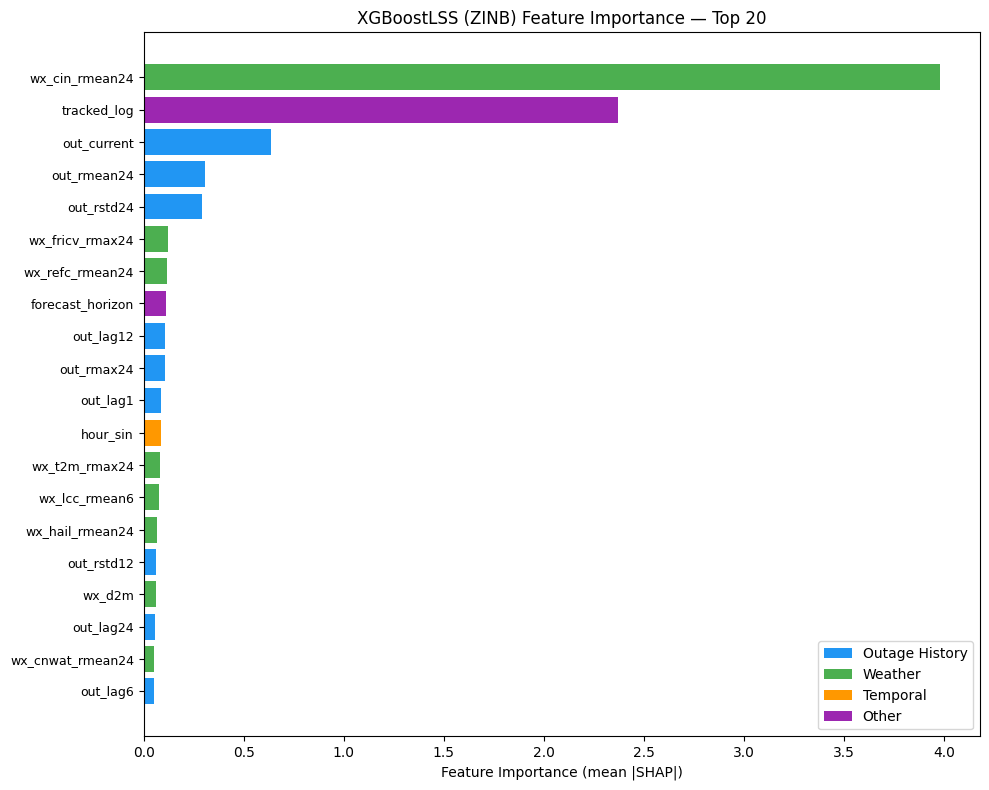

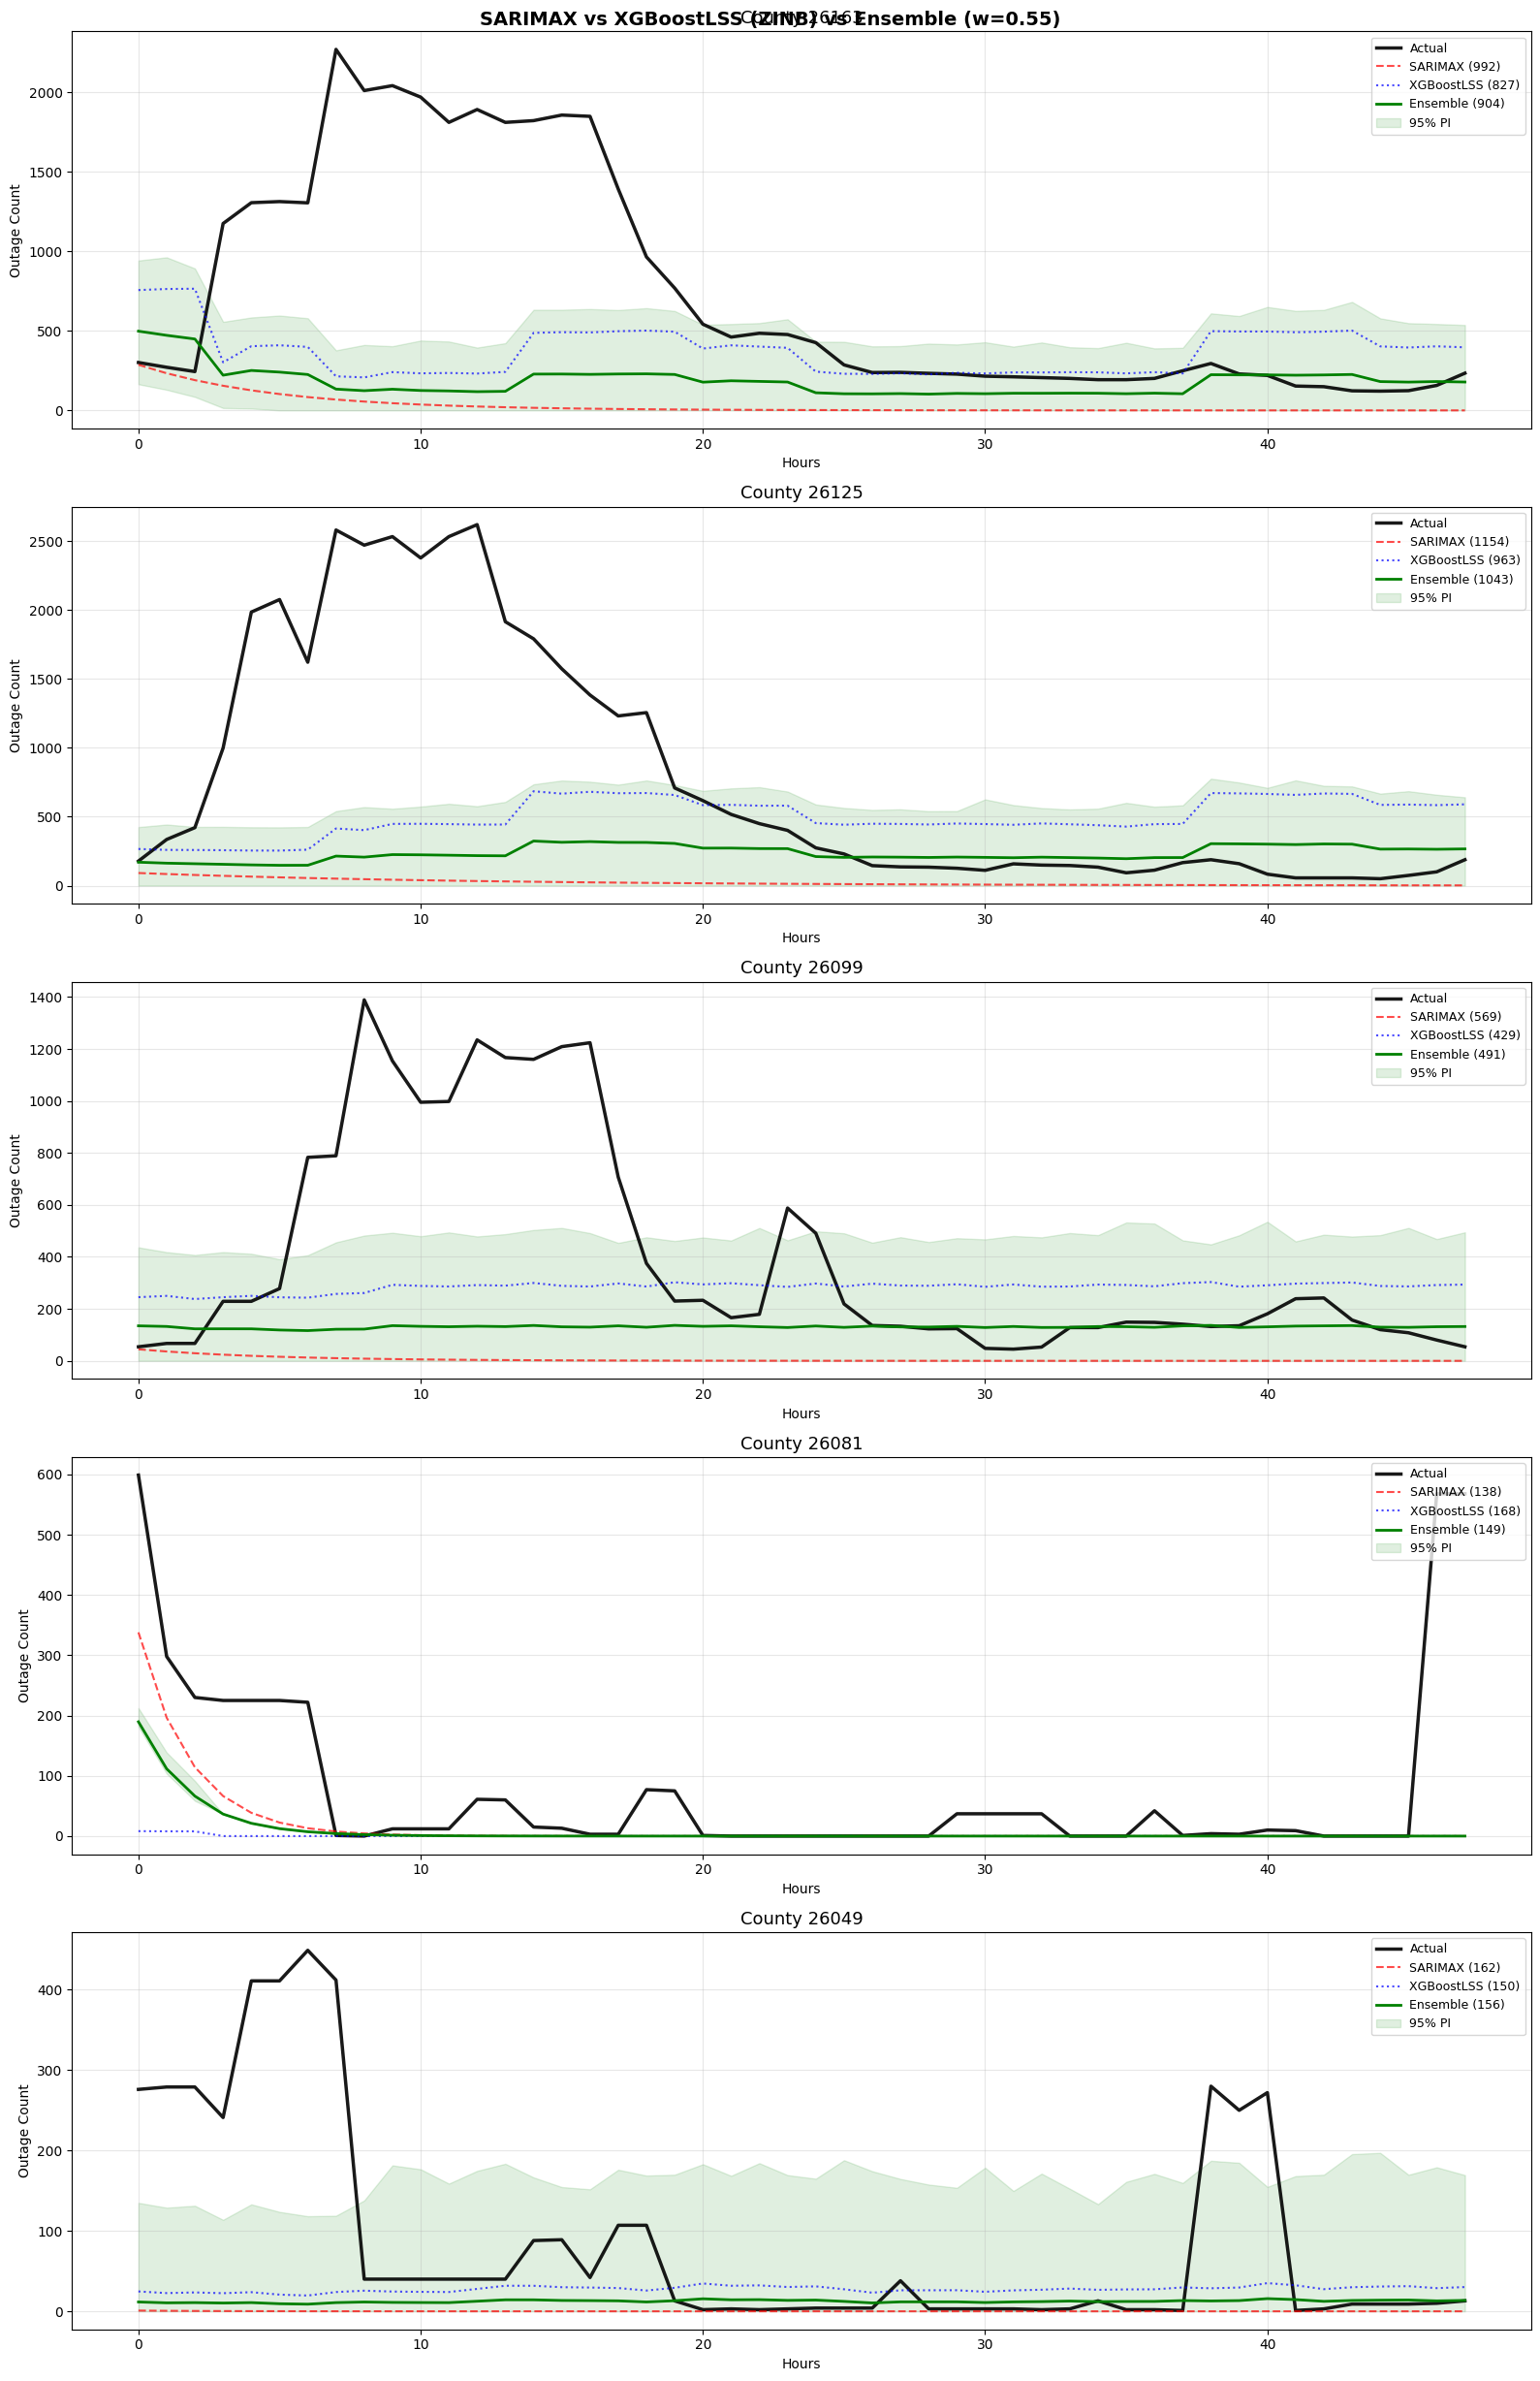

In [24]:
# 7.7 SHAP Analysis
print(f"\n--- 7.7 Feature Importance (for report) ---")
# Rebuild a small feature sample for SHAP
shap_feat_df = build_forecast(ds_train_sub, vtu, aw, weather_features)
shap_analysis(xm_val, shap_feat_df, fc, aw, RESULTS_DIR)
del shap_feat_df; gc.collect()

# 7.8 Plot
print("\n--- 7.8 Visualization ---")
fig,axes=plt.subplots(len(top5_locs),1,figsize=(16,5*len(top5_locs)))
if len(top5_locs)==1: axes=[axes]
for pi,loc in enumerate(top5_locs):
    ax=axes[pi]; ls=str(loc); li=locations.index(ls)
    tr=vt[:,li]; rng=range(avl)
    sp=sar_val[sar_val['location'].astype(str)==ls]['pred'].values[:avl]
    xd=xgb_val[xgb_val['location'].astype(str)==ls]
    xp=xd['pred'].values[:avl]
    ed=ens_val[ens_val['location'].astype(str)==ls]
    ep=ed['pred'].values[:avl]; el=ed['lower'].values[:avl]; eu=ed['upper'].values[:avl]
    ax.plot(rng,tr,'k-',label='Actual',lw=2.5,alpha=0.9)
    ax.plot(rng,sp,'r--',label=f'SARIMAX ({rmse(tr,sp):.0f})',lw=1.5,alpha=0.7)
    ax.plot(rng,xp,'b:',label=f'XGBoostLSS ({rmse(tr,xp):.0f})',lw=1.5,alpha=0.7)
    ax.plot(rng,ep,'g-',label=f'Ensemble ({rmse(tr,ep):.0f})',lw=2)
    ax.fill_between(rng,el,eu,alpha=0.12,color='green',label='95% PI')
    ax.set_title(f'County {ls}',fontsize=13)
    ax.set_xlabel('Hours'); ax.set_ylabel('Outage Count')
    ax.legend(loc='upper right',fontsize=9); ax.grid(True,alpha=0.3)
plt.suptitle(f'SARIMAX vs XGBoostLSS (ZINB) vs Ensemble (w={bw:.2f})',fontweight='bold',fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"validation_final.png"),dpi=150,bbox_inches='tight')
print("Validation plot saved!")

In [25]:
# ============================================================================
# 8. FINAL TEST PREDICTION
# ============================================================================
print(f"\n{'='*70}\n8. FINAL TEST PREDICTION\n{'='*70}")

# 8.1 Train on full data
print("\n--- 8.1 Train Final Models ---")
del xm_val; gc.collect()

print("Final SARIMAX (full data)...")
sar_final = {}
for loc in tqdm(locations, desc="Final SARIMAX"):
    sar_final[str(loc)] = safe_fit_sarimax(
        ds_train.out.sel(location=loc).values.astype(float), order=SARIMAX_ORDER)

gc.collect()
print("\nFinal XGBoostLSS (full data)...")
tdf2 = build_train(ds_train, aw, weather_features, max_samples=600000)
xm_final, ffc = train_model(tdf2, n_iter=XGBLSS_N_ITERATIONS, n_trials=XGBLSS_OPTUNA_TRIALS)
del tdf2; gc.collect()

# 8.2 Predict
print("\n--- 8.2 Test Predictions ---")
tts = pd.to_datetime(ds_test_48h.timestamp.values)

sar_test = generate_sarimax_predictions(sar_final, locations, tts)
tfd = build_forecast(ds_train, tts, aw, weather_features)
xgb_test = predict_model(xm_final, tfd, ffc)
ens_test = blend(sar_test, xgb_test, bw)

print(f"  SARIMAX:    {len(sar_test)} preds, mean={sar_test['pred'].mean():.2f}")
print(f"  XGBoostLSS: {len(xgb_test)} preds, mean={xgb_test['pred'].mean():.2f}")
print(f"  Ensemble:   {len(ens_test)} preds, mean={ens_test['pred'].mean():.2f} (w={bw:.2f})")

# 8.3 Save ALL
print("\n--- 8.3 Save Submissions ---")
sar_test.to_csv(os.path.join(RESULTS_DIR,"sarimax_pred_48h.csv"), index=False)
xgb_test.to_csv(os.path.join(RESULTS_DIR,"xgboostlss_pred_48h.csv"), index=False)
ens_test.to_csv(os.path.join(RESULTS_DIR,"ensemble_pred_48h.csv"), index=False)
print(f"  Saved: sarimax_pred_48h.csv, xgboostlss_pred_48h.csv, ensemble_pred_48h.csv")

# 8.4 Verify
print("\n--- 8.4 Verify Submission Format ---")
for fn, lb in [("xgboostlss_pred_48h.csv","XGBoostLSS"),("ensemble_pred_48h.csv","Ensemble")]:
    d = pd.read_csv(os.path.join(RESULTS_DIR, fn))
    assert d.shape[0]==3984, f"{lb}: {d.shape[0]} rows"
    assert all(c in d.columns for c in ['timestamp','location','pred','upper','lower'])
    assert (d['lower']<=d['pred']+1e-6).all(), f"{lb}: lower > pred"
    assert (d['pred']<=d['upper']+1e-6).all(), f"{lb}: pred > upper"
    assert (d['pred']>=0).all(), f"{lb}: negative pred"
    pw = (d['upper']-d['lower']).mean()
    print(f"  {lb}: {d.shape[0]} rows, pred mean={d['pred'].mean():.1f}, PI width={pw:.1f}")

# 8.5 Demo evaluation (noise)
print("\n--- 8.5 Demo Test Eval (random noise, not meaningful) ---")
print(f"  SARIMAX:    {np.nanmean(eval_county(test_truth,sar_test,locations)):.2f}")
print(f"  XGBoostLSS: {np.nanmean(eval_county(test_truth,xgb_test,locations)):.2f}")
print(f"  Ensemble:   {np.nanmean(eval_county(test_truth,ens_test,locations)):.2f}")



8. FINAL TEST PREDICTION

--- 8.1 Train Final Models ---
Final SARIMAX (full data)...


Final SARIMAX:   0%|          | 0/83 [00:00<?, ?it/s]


Final XGBoostLSS (full data)...
  Origins: 2136, horizons: [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 42, 48], est: 2,836,608
  Subsampled to 451 origins -> ~598,928
  Final: 596,189 samples, 188 features
  Target: mean=41.91, zero%=70.7%, max=23346

  Training ZINB XGBoostLSS: 596,189 samples, 188 features
  Optuna: 30 trials, 500 max rounds...


  0%|          | 0/30 [00:00<?, ?it/s]


Hyper-Parameter Optimization successfully finished.
  Number of finished trials:  30
  Best trial:
    Value: 456734.6041666667
    Params: 
    eta: 0.019324261980535676
    max_depth: 2
    min_child_weight: 3.126217323855373
    subsample: 0.7152131042436294
    colsample_bytree: 0.845744583520252
    gamma: 0.00041321148282791363
    booster: gbtree
    opt_rounds: 500
  Best: eta=0.0193, depth=2, rounds=500
  Trained!

--- 8.2 Test Predictions ---
  SARIMAX:    3984 preds, mean=10.08
  XGBoostLSS: 3984 preds, mean=27.13
  Ensemble:   3984 preds, mean=17.75 (w=0.55)

--- 8.3 Save Submissions ---
  Saved: sarimax_pred_48h.csv, xgboostlss_pred_48h.csv, ensemble_pred_48h.csv

--- 8.4 Verify Submission Format ---
  XGBoostLSS: 3984 rows, pred mean=27.1, PI width=113.1
  Ensemble: 3984 rows, pred mean=17.8, PI width=102.1

--- 8.5 Demo Test Eval (random noise, not meaningful) ---
  SARIMAX:    20.13
  XGBoostLSS: 27.50
  Ensemble:   22.23


In [26]:
# ============================================================================
# 9. SUMMARY
# ============================================================================
print(f"\n{'='*70}")
print("9. FINAL SUMMARY")
print(f"{'='*70}")
print(f"""
MODEL: XGBoostLSS with Zero-Inflated Negative Binomial (ZINB) distribution
       + SARIMAX(1,0,1) Ensemble

VALIDATION RESULTS:
  {'Metric':<22s} {'SARIMAX':>10s} {'XGBoostLSS':>12s} {'Ensemble':>10s}
  {'-'*58}
  {'Overall RMSE':<22s} {sa:>10.2f} {xa:>12.2f} {ea:>10.2f}
  {'s1 Normal RMSE':<22s} {s1s:>10.2f} {s1x:>12.2f} {s1e:>10.2f}
  {'s2 Extreme RMSE':<22s} {s2s:>10.2f} {s2x:>12.2f} {s2e:>10.2f}
  {'s3 F1 Score':<22s} {s3s:>10.4f} {s3x:>12.4f} {s3e:>10.4f}
  {'s4 Winkler':<22s} {'N/A':>10s} {s4x:>12.2f} {s4e:>10.2f}

ENSEMBLE WEIGHT: {bw:.0%} SARIMAX + {1-bw:.0%} XGBoostLSS

""")
print("="*70+"\nDone!\n"+"="*70)


9. FINAL SUMMARY

MODEL: XGBoostLSS with Zero-Inflated Negative Binomial (ZINB) distribution
       + SARIMAX(1,0,1) Ensemble

VALIDATION RESULTS:
  Metric                    SARIMAX   XGBoostLSS   Ensemble
  ----------------------------------------------------------
  Overall RMSE                68.36        69.82      64.18
  s1 Normal RMSE              43.40        48.55      43.17
  s2 Extreme RMSE            164.61       161.66     156.33
  s3 F1 Score                0.3938       0.5333     0.5862
  s4 Winkler                    N/A       879.54     877.78

ENSEMBLE WEIGHT: 55% SARIMAX + 45% XGBoostLSS


Done!
